In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [2]:
# Load dataset
df = pd.read_csv('../data/ai4i2020.csv')

print("✅ Dataset loaded successfully!")
print("\nShape of dataset:", df.shape)

print("\nColumns in dataset:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
df.head()

✅ Dataset loaded successfully!

Shape of dataset: (10000, 14)

Columns in dataset:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

First 5 rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
print("=== Dataset Information ===")
df.info()

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe()

=== Dataset Information ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: flo

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


=== Failure Distribution ===
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure Rate: 3.39%


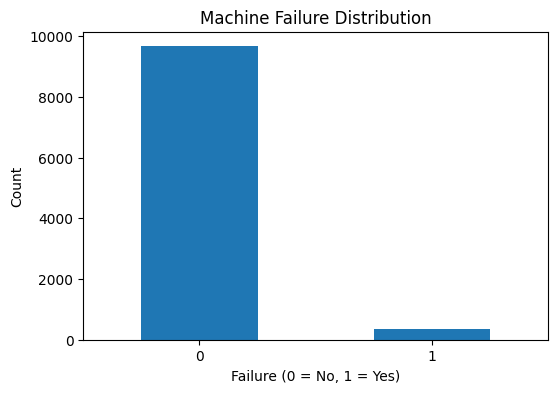

In [4]:
print("=== Failure Distribution ===")
print(df['Machine failure'].value_counts())

failure_rate = df['Machine failure'].mean() * 100
print(f"\nFailure Rate: {failure_rate:.2f}%")

# Plot
plt.figure(figsize=(6,4))

df['Machine failure'].value_counts().plot(kind='bar')

plt.title('Machine Failure Distribution')
plt.xlabel('Failure (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

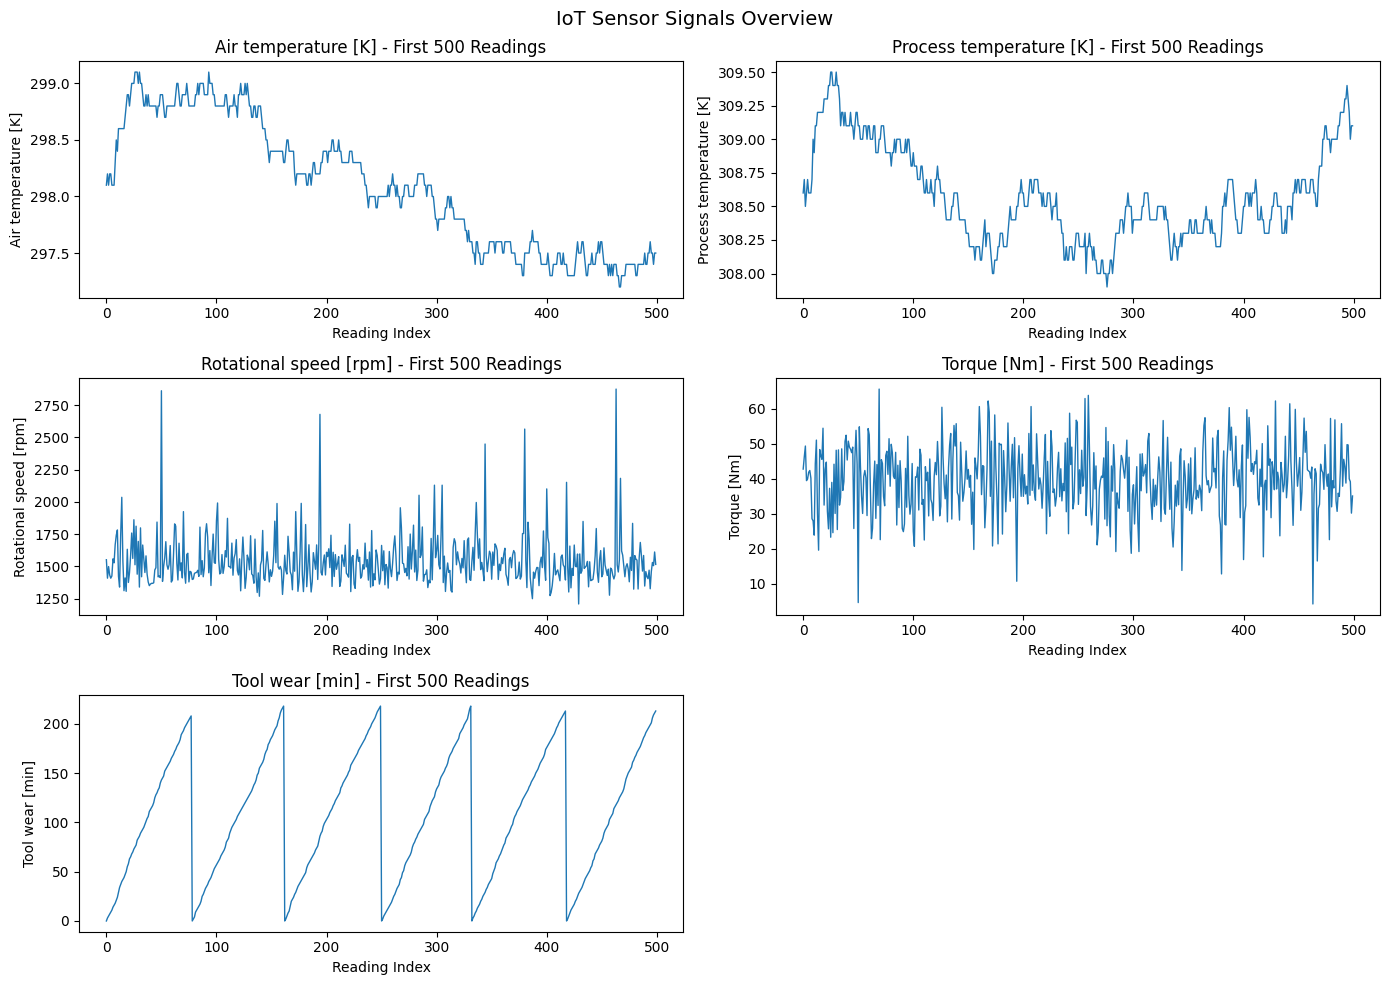

In [5]:
sensor_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

fig, axes = plt.subplots(3, 2, figsize=(14,10))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    axes[i].plot(df[col].values[:500], linewidth=1)
    axes[i].set_title(f'{col} - First 500 Readings')
    axes[i].set_xlabel('Reading Index')
    axes[i].set_ylabel(col)

# Hide empty subplot
axes[-1].axis('off')

plt.suptitle('IoT Sensor Signals Overview', fontsize=14)
plt.tight_layout()

plt.show()

In [6]:
# Reset index to maintain proper order
df = df.reset_index(drop=True)

window_size = 10

for col in sensor_cols:
    
    # Rolling mean
    df[f'{col}_roll_mean'] = (
        df[col]
        .rolling(window=window_size)
        .mean()
    )
    
    # Rolling standard deviation
    df[f'{col}_roll_std'] = (
        df[col]
        .rolling(window=window_size)
        .std()
    )
    
    # Rolling variance
    df[f'{col}_roll_var'] = (
        df[col]
        .rolling(window=window_size)
        .var()
    )

# Remove NaN rows created due to rolling window
df_rolled = df.dropna().reset_index(drop=True)

print("✅ Rolling features created!")

print("\nOriginal Shape:", df.shape)
print("New Shape:", df_rolled.shape)

print("\nTotal New Features Added:")
print(len([col for col in df_rolled.columns if 'roll' in col]))

print("\nSample Rolling Features:")
rolling_cols = [col for col in df_rolled.columns if 'roll' in col]
print(rolling_cols[:10])

df_rolled.head()

✅ Rolling features created!

Original Shape: (10000, 29)
New Shape: (9991, 29)

Total New Features Added:
15

Sample Rolling Features:
['Air temperature [K]_roll_mean', 'Air temperature [K]_roll_std', 'Air temperature [K]_roll_var', 'Process temperature [K]_roll_mean', 'Process temperature [K]_roll_std', 'Process temperature [K]_roll_var', 'Rotational speed [rpm]_roll_mean', 'Rotational speed [rpm]_roll_std', 'Rotational speed [rpm]_roll_var', 'Torque [Nm]_roll_mean']


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Air temperature [K]_roll_mean,Air temperature [K]_roll_std,Air temperature [K]_roll_var,Process temperature [K]_roll_mean,Process temperature [K]_roll_std,Process temperature [K]_roll_var,Rotational speed [rpm]_roll_mean,Rotational speed [rpm]_roll_std,Rotational speed [rpm]_roll_var,Torque [Nm]_roll_mean,Torque [Nm]_roll_std,Torque [Nm]_roll_var,Tool wear [min]_roll_mean,Tool wear [min]_roll_std,Tool wear [min]_roll_var
0,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,0,0,0,0,298.19,0.128668,0.016556,308.66,0.134990,0.018222,1521.6,113.060652,12782.711111,39.91,6.826655,46.603222,10.4,6.834553,46.711111
1,11,H29424,H,298.4,308.9,1782,23.9,24,0,0,0,0,0,0,298.22,0.139841,0.019556,308.69,0.152388,0.023222,1544.7,140.100004,19628.011111,38.02,8.377722,70.186222,12.8,6.988880,48.844444
2,12,H29425,H,298.6,309.1,1423,44.3,29,0,0,0,0,0,0,298.26,0.183787,0.033778,308.73,0.200278,0.040111,1546.2,138.545460,19194.844444,37.82,8.179622,66.906222,15.4,7.734483,59.822222
3,13,M14872,M,298.6,309.1,1339,51.1,34,0,0,0,0,0,0,298.31,0.202485,0.041000,308.79,0.213177,0.045444,1530.3,153.055582,23426.011111,37.99,8.459899,71.569889,18.3,8.769265,76.900000
4,14,M14873,M,298.6,309.2,1742,30.0,37,0,0,0,0,0,0,298.35,0.217307,0.047222,308.85,0.236878,0.056111,1561.2,162.150684,26292.844444,37.04,8.798131,77.407111,21.3,9.569047,91.566667


In [7]:
print("=== Final Dataset Summary ===")

print(f"Total samples: {df_rolled.shape[0]}")
print(f"Total features: {df_rolled.shape[1]}")
print(f"Failure cases: {df_rolled['Machine failure'].sum()}")

failure_rate = (
    df_rolled['Machine failure'].mean()
) * 100

print(f"Failure Rate: {failure_rate:.2f}%")

# Save feature list
with open('../src/feature_list.txt', 'w') as f:
    for col in df_rolled.columns:
        f.write(col + '\n')

print("\n✅ Feature list saved!")
print("📁 Saved at: src/feature_list.txt")

=== Final Dataset Summary ===
Total samples: 9991
Total features: 29
Failure cases: 339
Failure Rate: 3.39%

✅ Feature list saved!
📁 Saved at: src/feature_list.txt
